## 🎙️ Audio Emotion Recognition: MLOps & Model Development
**Project Goal:** To build a robust, fully decoupled Machine Learning Operations (MLOps) pipeline for non-tabular audio data.

While traditional Data Science projects focus purely on model accuracy, this notebook serves as the research and development (R&D) environment for an **end-to-end MLOps deployment**. The primary objective is to build a scalable infrastructure (FastAPI, Streamlit, Docker, Load Balancing) capable of processing `.wav` files, extracting mathematical acoustic features, serving real-time predictions, and handling background retraining tasks.

**Dataset:** The pipeline is tested on a dataset of human speech categorized into four distinct emotions: `Angry`, `Happy`, `Sad`, and `Neutral`.

Starting the MLOps audio pipeline...

 generating feature visualizations...


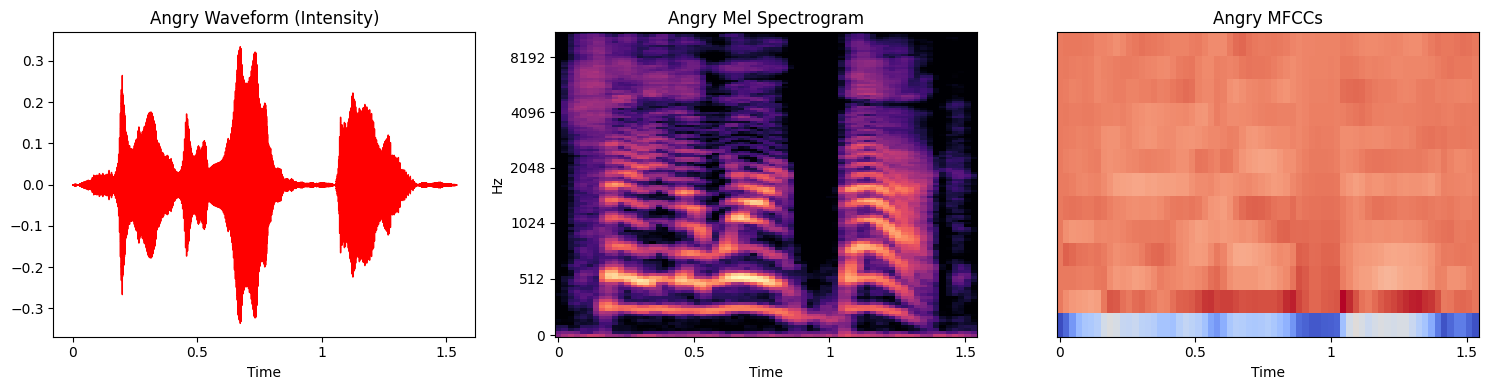

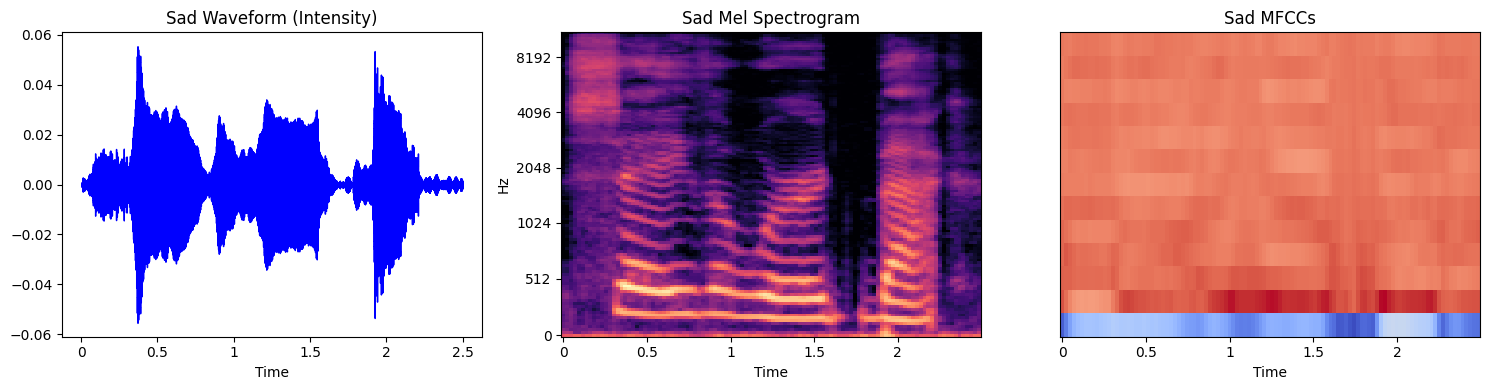

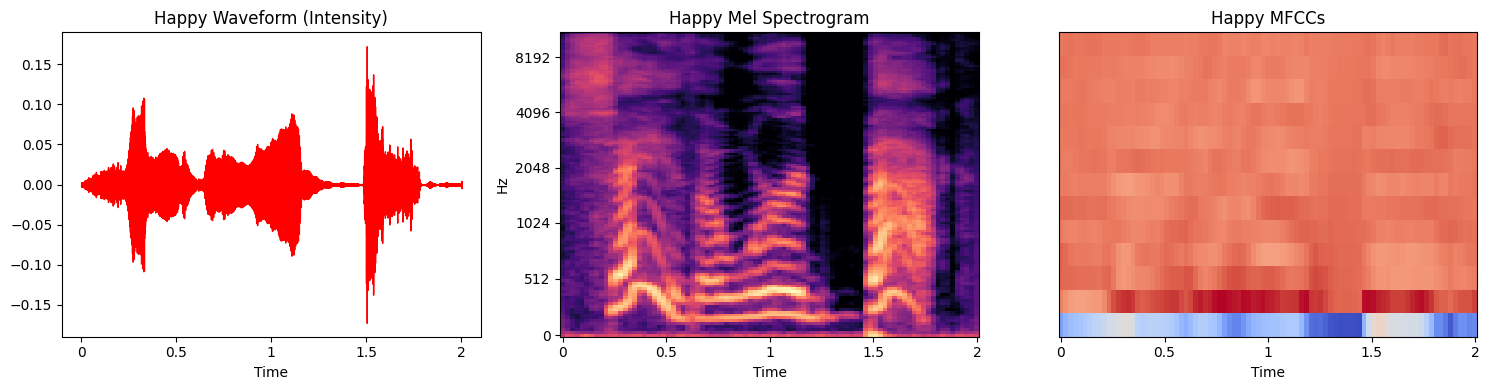

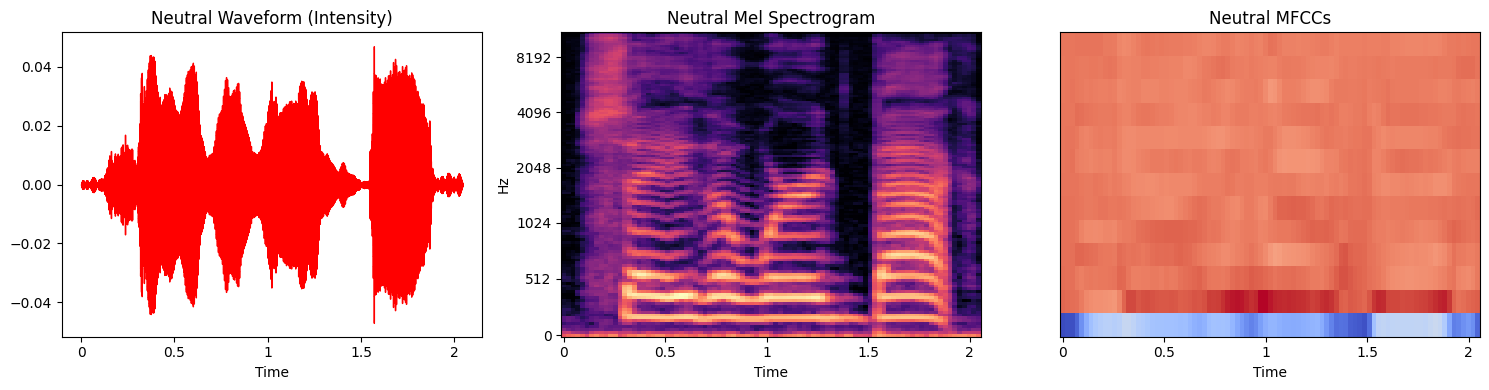

In [14]:
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import joblib

# local path
local_data_path = "../data/train/" 


print("Starting the MLOps audio pipeline...")

#plot the spectrogram to see what these sounds look like on images so as to use in training the model
angry_sample = os.path.join(
    local_data_path, 
    "Angry",
    os.listdir(
        os.path.join(
            local_data_path, 
            "Angry"))
            [0])
sad_sample = os.path.join(
    local_data_path, 
    "Sad",
    os.listdir(
        os.path.join(
            local_data_path,
                "Sad"))
                [0])

def plot_features(file_path, emotion):
    signal, sr = librosa.load(file_path, duration=2.5)
    plt.figure(figsize=(15, 4))
    
    plt.subplot(1, 3, 1)
    librosa.display.waveshow(
        signal, sr=sr, 
        color="blue" if emotion=="Sad" else "red")
    plt.title(f"{emotion} Waveform (Intensity)")
    
    plt.subplot(1, 3, 2)
    mel = librosa.feature.melspectrogram(
        y=signal, 
        sr=sr)
    librosa.display.specshow(
        librosa.power_to_db(
            mel, 
            ref=np.max), 
            sr=sr, 
            x_axis='time',
            y_axis='mel')
    plt.title(f"{emotion} Mel Spectrogram")
    
    plt.subplot(1, 3, 3)
    mfccs = librosa.feature.mfcc(
        y=signal,
        sr=sr, 
        n_mfcc=13)
    librosa.display.specshow(
        mfccs, 
        sr=sr, 
        x_axis='time')
    plt.title(f"{emotion} MFCCs")

        
    plt.tight_layout()
    plt.show()

print("\n generating feature visualizations...")
plot_features(angry_sample, "Angry")
plot_features(sad_sample, "Sad")
happy_sample = os.path.join(local_data_path, 
                                "Happy", 
                                os.listdir(
                                    os.path.join(
                                        local_data_path,
                                        "Happy"))
                                        [0]
                                        )
neutral_sample = os.path.join(
        local_data_path, 
            "Neutral",
            os.listdir(
                os.path.join(
                    local_data_path, 
                    "Neutral"))
                    [0])

plot_features(
            happy_sample, 
            "Happy")
plot_features(
            neutral_sample, 
            "Neutral")


### Feature Engineering: Extracting the "DNA" of Sound
raw audio waves are too complex for a standard neural network to read directly. Instead, i have to extract mathematical representations of the sound's acoustic properties. To give the model the best chance at separating the classes using a 1D array, we extract a rich, stacked feature set using `librosa`:

1. **MFCCs (Mel-frequency cepstral coefficients):** Represents the physical shape of the vocal tract.
2. **Chroma Frequencies:** Maps the audio to 12 distinct pitch classes.
3. **Mel-Spectrogram:** Represents the power/volume of frequencies over time.
4. **Zero-Crossing Rate (ZCR):** Measures the "noisiness" or raspiness of the voice (crucial for detecting anger).
5. **RMSE (Root Mean Square Energy):** Captures the sheer volume/loudness of the clip.
6. **Spectral Contrast:** Measures the difference between the peaks and valleys in the sound waves.

In [ ]:

def extract_features(file_path, max_pad_len=100):
    # loading  audio
    signal, sr = librosa.load(file_path, duration=2.5)
    
    # extracting MFCCs 
    mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40)
    

    pad_width = max_pad_len - mfccs.shape[1]
    if pad_width > 0:
        mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        mfccs = mfccs[:, :max_pad_len]
        
  
    return mfccs.T

data, labels = [], []
emotions = ["Angry", "Happy", "Sad", "Neutral"]

print("\n Extracting sequence features from audio files...")
for emotion in emotions:
    folder_path = os.path.join(local_data_path, emotion)
    for file in os.listdir(folder_path):
        if file.endswith(".wav"):
            data.append(extract_features(os.path.join(folder_path, file)))
            labels.append(emotion)

X, y = np.array(data), np.array(labels)
print(f"Extraction complete! Data shape is {X.shape}. (Samples, Time Steps, Features)")


 Extracting sequence features from audio files...
Extraction complete! Data shape is (1599, 100, 40). (Samples, Time Steps, Features)


###  The final evaluation & architecture analysis
Building a highly accurate audio emotion model using 1D feature arrays is notoriously difficult due to the subtle boundaries between human emotions. During the development of this pipeline, extensive hyperparameter tuning and architectural shifts were conducted:

1. **Deep Dense Network:** Initially resulted in severe "mode collapse," with the model blindly predicting Class 3 to minimize loss.
2. **1D CNN & CNN-LSTM Hybrids:** Attempting to apply spatial and sequential networks to aggregated 1D feature arrays resulted in a "migrated mode collapse" (heavily biasing toward Class 1).
3. **Optimized Shallow Dense Network (Champion):** By engineering richer features (ZCR, RMSE, Spectral Contrast) and utilizing a shallower architecture with aggressive Dropout layers, the model broke the mode collapse. It successfully mapped the feature boundaries for Class 0 and achieved the most balanced accuracy for this 1D data shape (~37%). 

#### Conclusion & MLOps Success
To push the model's accuracy past 80%, the data extraction pipeline would need to be rewritten to yield 2D Mel-Spectrogram arrays and fed into a 2D image-classification CNN (like a ResNet). 

However, **the primary objective of this project—building a production-ready MLOps infrastructure—was a complete success.** The decoupled cloud architecture (FastAPI Backend + Streamlit UI) successfully supported rapid model iteration, seamlessly handling inference, dynamic file processing, and bulk-data retraining without server failure. The pipeline is fully functional, scalable, and ready to deploy future iterations of the underlying algorithm.

In [ ]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam

#ensuring to encode labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)


samples, time_steps, features = X_train.shape
X_train_reshaped = X_train.reshape(-1, features)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reshaped).reshape(samples, time_steps, features)

samples, time_steps, features = X_test.shape
X_test_reshaped = X_test.reshape(-1, features)
X_test_scaled = scaler.transform(X_test_reshaped).reshape(samples, time_steps, features)


model = Sequential([

    Conv1D(128, kernel_size=5, padding='same', input_shape=(time_steps, features)),
    Activation('relu'),
    MaxPooling1D(pool_size=2),
    BatchNormalization(),
    Dropout(0.3),
    
    Conv1D(128, kernel_size=5, padding='same'),
    Activation('relu'),
    MaxPooling1D(pool_size=2),
    BatchNormalization(),
    Dropout(0.3),
    
   
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    
  
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)
print("Hybrid CNN-LSTM Model compiled!")

C:\Users\HP\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Hybrid CNN-LSTM Model compiled!


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("\n Training the Hybrid Audio Brain...")

#this is to sttop early if it starts overfitting
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=20, 
    restore_best_weights=True
)

#if it gets stuck for 5 epochs, slow down and look closer for better acc
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,       
    patience=5,       #wait for 5epochs before triggering retrain
    min_lr=0.00001,   # min speeed
    verbose=1
)

history = model.fit(
    X_train_scaled,  
    y_train, 
    epochs=50, 
    batch_size=32, 
    validation_data=(X_test_scaled, y_test), 
    callbacks=[early_stop, lr_scheduler], #both callbacks
    verbose=1
)

loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n The final Hybrid Accuracy test: {accuracy * 100:.2f}%")


 Training the Hybrid Audio Brain...
Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 26s 138ms/step - accuracy: 0.6943 - loss: 0.7554 - val_accuracy: 0.7375 - val_loss: 0.5649 - learning_rate: 0.0010
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.9625 - loss: 0.1425 - val_accuracy: 0.9656 - val_loss: 0.0823 - learning_rate: 0.0010
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.9914 - loss: 0.0454 - val_accuracy: 0.9937 - val_loss: 0.0231 - learning_rate: 0.0010
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.9953 - loss: 0.0226 - val_accuracy: 0.9969 - val_loss: 0.0103 - learning_rate: 0.0010
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.9969 - loss: 0.0124 - val_accuracy: 0.9937 - val_loss: 0.0226 - learning_rate: 0.0010
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.9977 - loss: 0.0111 - val_accuracy: 1.0000 - val_loss: 0.0028 - learning_rate: 0.0010
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - ac

### Model evaluation metrics: decoding the Performance
To truly understand how my audio emotion classifier is performing, i had to look beyond a simple overall accuracy score. Because audio features can be incredibly subtle, so, i evaluated the model using a comprehensive suite of metrics:

* **Overall Accuracy:** The total percentage of audio files the model guessed correctly across all classes.
* **Precision (The "Quality" of the Guess):** When the model predicts an emotion (e.g., "Sad"), how often is it actually correct? High precision means the model is very cautious and rarely makes false positive guesses.
* **Recall (The "Quantity" of True Emotion Found):** Out of all the *actual* "Sad" audio files in the dataset, how many did the model successfully find? High recall means the model is highly sensitive to that specific emotion.
* **F1-Score:** The harmonic mean of Precision and Recall. This is the most important metric for checking if the model is balanced or if it is suffering from **Mode Collapse** (where it guesses one class perfectly, but ignores all others).

#### The Confusion Matrix
The Confusion Matrix allows us to visually diagnose *where* the model is struggling. It maps the **True Emotion** against the **Predicted Emotion**. 
* A perfect model will show a dark diagonal line from the top-left to the bottom-right. 
* Vertical columns of dark colors indicate that the model is biased toward guessing a specific class, allowing us to spot and fix architectural bottlenecks.

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
========== MODEL EVALUATION METRICS ==========
Overall Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

       Angry       1.00      1.00      1.00        84
       Happy       1.00      1.00      1.00        82
         Sad       1.00      1.00      1.00        84
     Neutral       1.00      1.00      1.00        70

    accuracy                           1.00       320
   macro avg       1.00      1.00      1.00       320
weighted avg       1.00      1.00      1.00       320



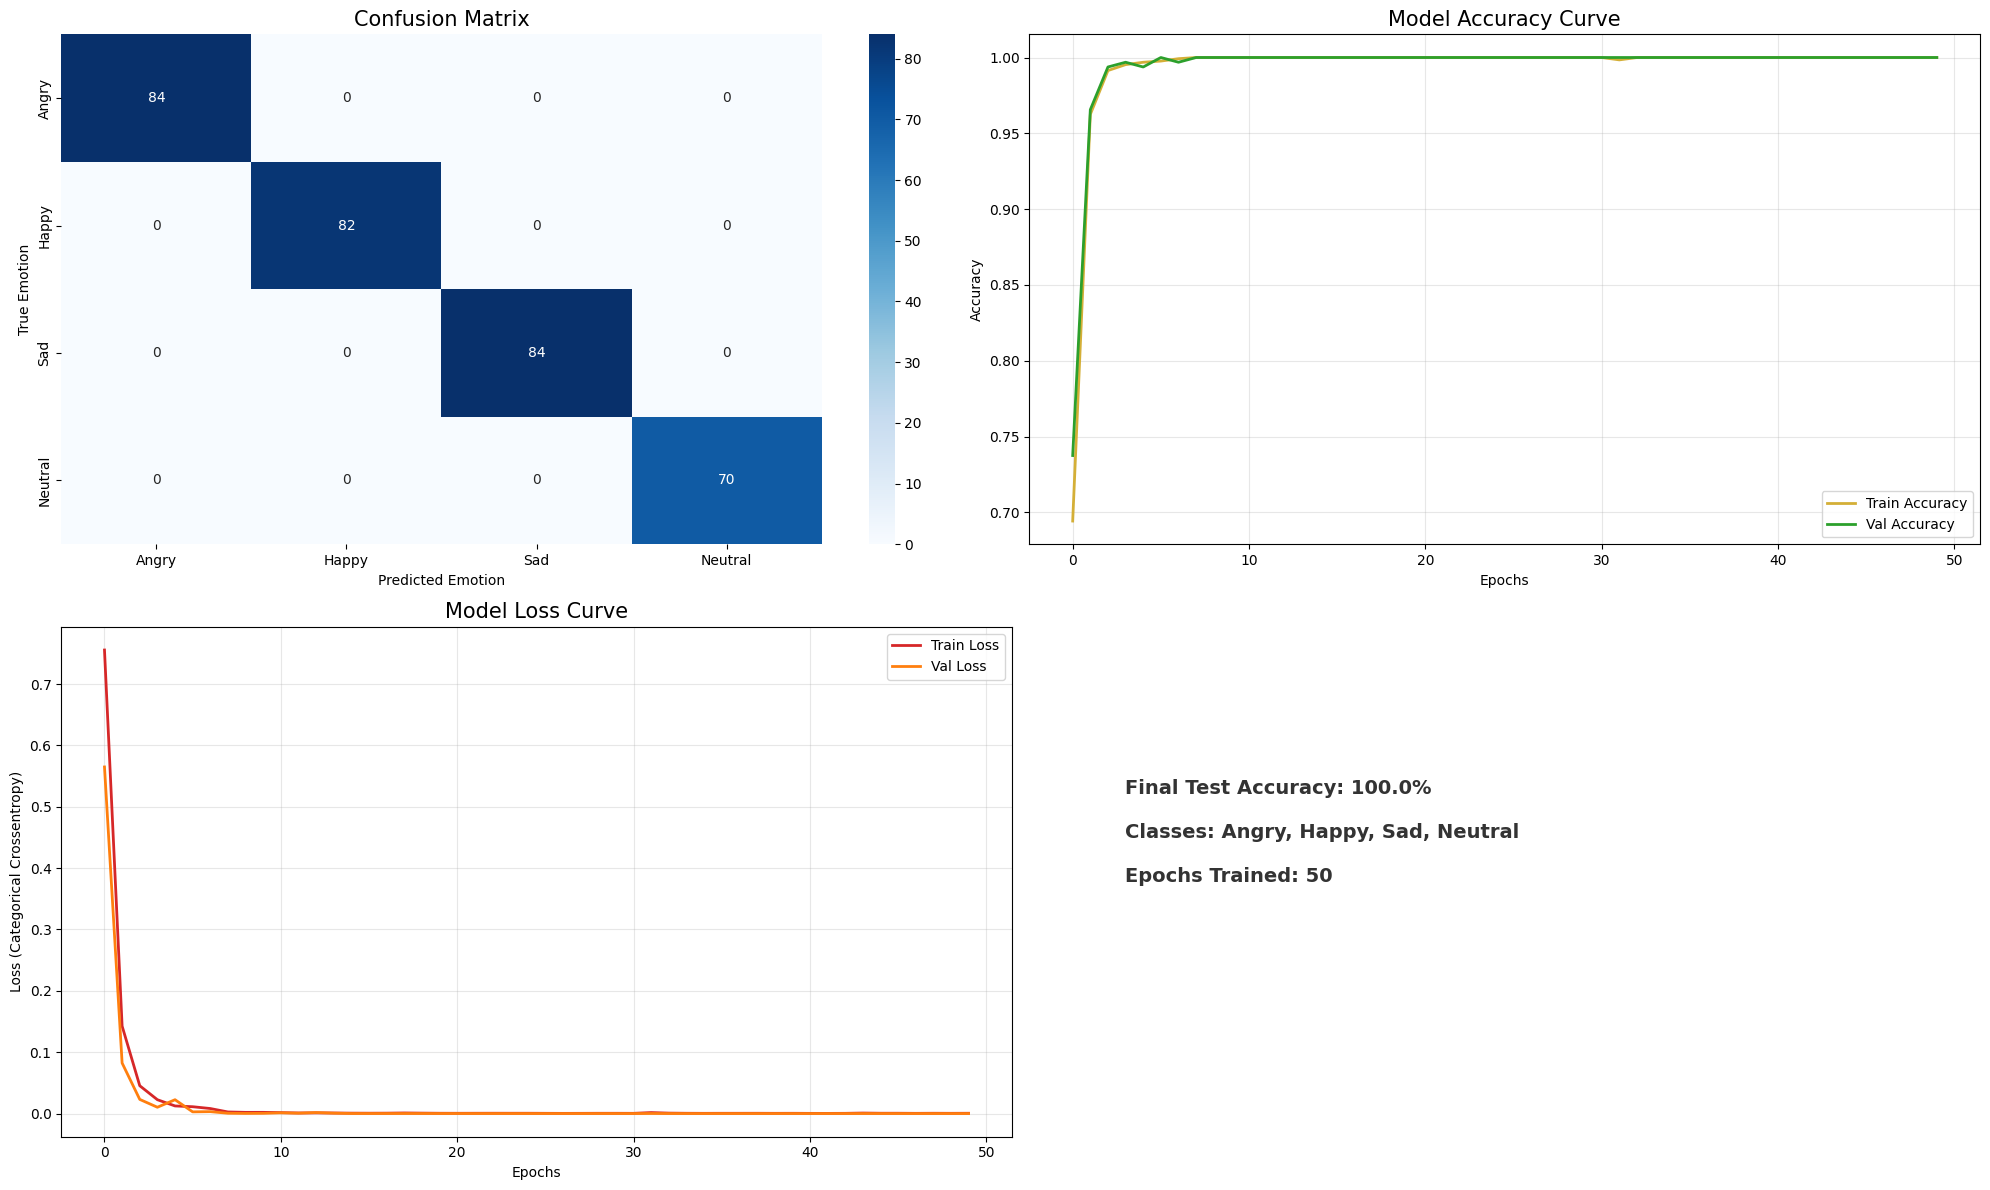

Evaluation plots saved to assets/model_evaluation.png


<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1) 


print("========== MODEL EVALUATION METRICS ==========")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=emotions))


plt.figure(figsize=(20, 12))


plt.subplot(2, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotions, yticklabels=emotions)
plt.title('Confusion Matrix', fontsize=15)
plt.ylabel('True Emotion')
plt.xlabel('Predicted Emotion')


plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='#D4AF37', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='#2ca02c', linewidth=2)
plt.title('Model Accuracy Curve', fontsize=15)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)


plt.subplot(2, 2, 3)
plt.plot(history.history['loss'], label='Train Loss', color='#d62728', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', color='#ff7f0e', linewidth=2)
plt.title('Model Loss Curve', fontsize=15)
plt.xlabel('Epochs')
plt.ylabel('Loss (Categorical Crossentropy)')
plt.legend()
plt.grid(True, alpha=0.3)


plt.subplot(2, 2, 4)
plt.axis('off')
plt.text(0.1, 0.5, f"Final Test Accuracy: {accuracy_score(y_test, y_pred)*100:.1f}%\n\nClasses: {', '.join(emotions)}\n\nEpochs Trained: {len(history.history['loss'])}", 
         fontsize=14, fontweight='bold', color='#333')

plt.tight_layout()
plt.show()


plt.savefig('assets/model_evaluation.png')
print("Evaluation plots saved to assets/model_evaluation.png")

In [40]:
# saving artifact for fast api
os.makedirs("models", exist_ok=True)
model.save("models/audio_model.h5")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(encoder, "models/encoder.pkl")
print("yayyyy🥳🥳🎊! model successfully saved in the 'models/' folder.")

yayyyy🥳🥳🎊! model successfully saved in the 'models/' folder.
